# 手寫阿拉伯數字辨識 完整版

## 載入套件

In [ ]:
import os, sys
from pathlib import Path
import shutil
from typing import Sized, cast

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchmetrics
import torchvision
from PIL import Image
from torch import nn, optim
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchinfo import summary
from torchvision import transforms
from torchvision.datasets import MNIST

## 設定參數

In [ ]:
# 判斷是否為 Colab 環境
is_colab = 'google.colab' in sys.modules
base_path = Path('/content/drive/MyDrive/colab_env') if is_colab else Path('.')
PATH_DATASETS = base_path / "data"  # 預設路徑
BATCH_SIZE = 1024  # 批量
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'mps'

## 步驟1：載入 MNIST 手寫阿拉伯數字資料

In [3]:
# 下載 MNIST 手寫阿拉伯數字 訓練資料
train_ds = MNIST(PATH_DATASETS, train=True, download=True, transform=transforms.ToTensor())

# 下載測試資料
test_ds = MNIST(PATH_DATASETS, train=False, download=True, transform=transforms.ToTensor())

# 訓練/測試資料的維度
print(train_ds.data.shape, test_ds.data.shape)

torch.Size([60000, 28, 28]) torch.Size([10000, 28, 28])


## 步驟2：資料探索

In [4]:
train_ds.data.shape, train_ds.targets.shape

(torch.Size([60000, 28, 28]), torch.Size([60000]))

In [5]:
# 訓練資料前10筆圖片的數字
train_ds.targets[:10]

tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4])

In [6]:
# 顯示第1張圖片內含值
train_ds.data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [7]:
# 將非0的數字轉為1，顯示第1張圖片
data = train_ds.data[0].clone()
data[data > 0] = 1
data = data.numpy()

# 將轉換後二維內容顯示出來，隱約可以看出數字為 5
text_image: list[str] = []
for i in range(data.shape[0]):
    text_image.append(''.join(data[i].astype(str)))
text_image

['0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000001111111111110000',
 '0000000011111111111111110000',
 '0000000111111111111111100000',
 '0000000111111111110000000000',
 '0000000011111110110000000000',
 '0000000001111100000000000000',
 '0000000000011110000000000000',
 '0000000000011110000000000000',
 '0000000000001111110000000000',
 '0000000000000111111000000000',
 '0000000000000011111100000000',
 '0000000000000001111100000000',
 '0000000000000000011110000000',
 '0000000000000011111110000000',
 '0000000000001111111100000000',
 '0000000000111111111000000000',
 '0000000011111111110000000000',
 '0000001111111111000000000000',
 '0000111111111100000000000000',
 '0000111111110000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000']

In [8]:
# 將非0的數字轉為1，顯示第2張圖片
data = train_ds.data[1].clone()
data[data > 0] = 1
data = data.numpy()

# 將轉換後二維內容顯示出來，隱約可以看出數字為 5
text_image: list[str] = []
for i in range(data.shape[0]):
    text_image.append(''.join(data[i].astype(str)))
text_image

['0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000001111100000000',
 '0000000000000011111100000000',
 '0000000000000111111111000000',
 '0000000000011111111111000000',
 '0000000000011111111111000000',
 '0000000000111111111111000000',
 '0000000001111111110011100000',
 '0000000011111100000011100000',
 '0000000111111100000011100000',
 '0000000111100000000011100000',
 '0000000111000000000011100000',
 '0000001111000000000011100000',
 '0000001111000000001111100000',
 '0000001110000000011111000000',
 '0000001110000000111100000000',
 '0000001110000001111000000000',
 '0000001111111111111000000000',
 '0000001111111111100000000000',
 '0000001111111110000000000000',
 '0000000111111100000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000']

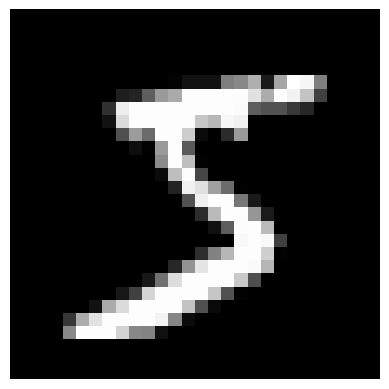

In [9]:
# 顯示第1張圖片圖像
# 第一筆資料
X = train_ds.data[0]

# 繪製點陣圖，cmap='gray':灰階
plt.imshow(X.reshape(28, 28), cmap='gray')

# 隱藏刻度
plt.axis('off')

# 顯示圖形
plt.show()

## 步驟3：特徵工程，此步驟無需進行

In [10]:
# train_ds.data = train_ds.data / 255.0
# test_ds.data = test_ds.data / 255.0

## 步驟4：資料分割，此步驟無需進行，載入MNIST資料時，已經切割好了

## 設定 TensorBoard，監控訓練過程的核心指標

In [11]:
# 清除舊的 log 目錄，避免多次執行時紀錄互相干擾
dirpath = 'runs/mnist_experiment_1'
if os.path.exists(dirpath) and os.path.isdir(dirpath):
    shutil.rmtree(dirpath)

# 建立 SummaryWriter，指定 log 存放目錄
writer = SummaryWriter('runs/mnist_experiment_1')

## 步驟5：建立模型結構

In [12]:
# 建立模型
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 256),
    nn.Dropout(0.2),
    nn.Linear(256, 10),
    # 使用nn.CrossEntropyLoss()時，不需要將輸出經過softmax層，否則計算的損失會有誤
    # nn.Softmax(dim=1)
).to(device)

In [13]:
# 寫入訓練資料的圖像方格與模型結構圖，方便在 TensorBoard 檢視模型輸入與架構
sample_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
sample_data, _ = next(iter(sample_loader))
img_grid = torchvision.utils.make_grid(sample_data)
writer.add_image('train_samples', img_grid)
writer.add_graph(model, sample_data.to(device))

## 步驟6：結合訓練資料及模型，進行模型訓練

In [14]:
epochs = 10
lr = 0.1

# 建立 DataLoader
train_loader = DataLoader(train_ds, batch_size=600)

# 設定優化器(optimizer)
# optimizer = optim.Adam(model.parameters(), lr=lr)
optimizer = optim.Adadelta(model.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

model.train()
loss_list: list[float] = []
correct = y_count = 0
step = 0
for epoch in range(epochs):
    data: torch.Tensor
    target: torch.Tensor
    epoch_loss_total = 0.0
    epoch_correct_total = 0
    epoch_count_total = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        # if batch_idx == 0 and epoch == 1: print(data.shape)

        optimizer.zero_grad()
        output: torch.Tensor = model(data)

        pred = output.argmax(dim=1, keepdim=True)
        # 正確筆數
        batch_correct = pred.eq(target.view_as(pred)).sum().item()
        correct += batch_correct
        y_count += pred.shape[0]

        # if batch_idx == 0 and epoch == 1: print(output.shape, target.shape)
        loss = criterion.forward(output, target)
        loss_list.append(loss.item())
        loss.backward()
        optimizer.step()

        # 累計本 epoch 的核心指標，供 epoch 結束後寫入 TensorBoard
        epoch_loss_total += loss.item() * pred.shape[0]
        epoch_correct_total += batch_correct
        epoch_count_total += pred.shape[0]

        # 將每個批次的損失、準確率、學習率寫入 TensorBoard
        writer.add_scalar('Loss/train_step', loss.item(), step)
        writer.add_scalar('Accuracy/train_step', batch_correct / pred.shape[0], step)
        writer.add_scalar('LearningRate', optimizer.param_groups[0]['lr'], step)
        step += 1

        if (batch_idx + 1) % 10 == 0:
            acc = correct / y_count
            correct = y_count = 0
            batch = (batch_idx + 1) * len(data)
            data_count = len(cast(Sized, train_loader.dataset))
            print(f'Epoch {epoch + 1}: [{batch:5d} / {data_count}]  Accuracy: {acc*100:.2f}%,  Loss: {loss.item():.6f}')

    # 每個 epoch 結束後，寫入平均損失、平均準確率，以及權重、梯度的分布狀況
    writer.add_scalar('Loss/train_epoch', epoch_loss_total / epoch_count_total, epoch)
    writer.add_scalar('Accuracy/train_epoch', epoch_correct_total / epoch_count_total, epoch)
    for name, param in model.named_parameters():
        writer.add_histogram(f'Weights/{name}', param, epoch)
        if param.grad is not None:
            writer.add_histogram(f'Gradients/{name}', param.grad, epoch)

Epoch 1: [ 6000 / 60000]  Accuracy: 38.90%,  Loss: 2.040197
Epoch 1: [12000 / 60000]  Accuracy: 66.03%,  Loss: 1.800682
Epoch 1: [18000 / 60000]  Accuracy: 69.83%,  Loss: 1.633375
Epoch 1: [24000 / 60000]  Accuracy: 75.93%,  Loss: 1.369669
Epoch 1: [30000 / 60000]  Accuracy: 78.62%,  Loss: 1.203123
Epoch 1: [36000 / 60000]  Accuracy: 79.80%,  Loss: 1.017659
Epoch 1: [42000 / 60000]  Accuracy: 81.27%,  Loss: 0.991453
Epoch 1: [48000 / 60000]  Accuracy: 81.85%,  Loss: 0.828793
Epoch 1: [54000 / 60000]  Accuracy: 82.70%,  Loss: 0.760787
Epoch 1: [60000 / 60000]  Accuracy: 87.25%,  Loss: 0.587519
Epoch 2: [ 6000 / 60000]  Accuracy: 85.17%,  Loss: 0.610571
Epoch 2: [12000 / 60000]  Accuracy: 85.12%,  Loss: 0.677147
Epoch 2: [18000 / 60000]  Accuracy: 82.85%,  Loss: 0.691484
Epoch 2: [24000 / 60000]  Accuracy: 86.43%,  Loss: 0.583786
Epoch 2: [30000 / 60000]  Accuracy: 86.33%,  Loss: 0.612109
Epoch 2: [36000 / 60000]  Accuracy: 85.83%,  Loss: 0.512627
Epoch 2: [42000 / 60000]  Accuracy: 86.3

## CrossEntropyLoss 可接納 output, target 維度不同，[600, 10]及[600]

## 對訓練過程的損失繪圖

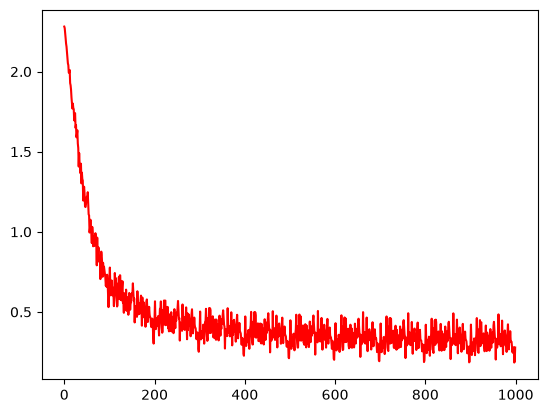

In [15]:
plt.plot(loss_list, 'r')

## 步驟7：評分(Score Model)

In [16]:
# 建立 DataLoader
test_loader = DataLoader(test_ds, shuffle=False, batch_size=test_ds.targets.shape[0])

model.eval()
test_loss = 0
correct = 0
data: torch.Tensor
target: torch.Tensor
for data, target in test_loader:
    data, target = data.to(device), target.to(device)
    output: torch.Tensor = model(data)

    # sum up batch loss
    test_loss += criterion.forward(output, target).item()

    # 預測
    pred = output.argmax(dim=1, keepdim=True)

    # 正確筆數
    correct += pred.eq(target.view_as(pred)).sum().item()

# 顯示測試結果
data_count = len(cast(Sized, test_loader.dataset))
percentage = 100.0 * correct / data_count
print(f'平均損失: {test_loss:.4f}, 準確率: {correct}/{data_count} ({percentage:.0f}%)\n')

# 將測試集的損失與準確率寫入 TensorBoard，方便與訓練指標比較
writer.add_scalar('Loss/test', test_loss, epochs)
writer.add_scalar('Accuracy/test', percentage / 100, epochs)

平均損失: 0.3006, 準確率: 9156/10000 (92%)



## 混淆矩陣(Confusion Matrix)，寫入 TensorBoard

In [17]:
# 計算測試集的混淆矩陣
cm = torchmetrics.functional.confusion_matrix(pred.reshape(-1), target, task='multiclass', num_classes=10)

# 繪製混淆矩陣圖像
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm.cpu().numpy(), cmap='Blues')
ax.set_xlabel('預測類別')
ax.set_ylabel('實際類別')
ax.set_title('Confusion Matrix')
ax.set_xticks(range(10))
ax.set_yticks(range(10))
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j].item(), ha='center', va='center', fontsize=8)
fig.colorbar(im)

# 寫入 TensorBoard
writer.add_figure('ConfusionMatrix/test', fig)
plt.show()

/Users/rikenmi/Work/study/python/PyTorch_Book/.venv/lib/python3.12/site-packages/torch/utils/tensorboard/_utils.py:24: UserWarning: Glyph 23526 (\N{CJK UNIFIED IDEOGRAPH-5BE6}) missing from font(s) DejaVu Sans.
  canvas.draw()
/Users/rikenmi/Work/study/python/PyTorch_Book/.venv/lib/python3.12/site-packages/torch/utils/tensorboard/_utils.py:24: UserWarning: Glyph 38555 (\N{CJK UNIFIED IDEOGRAPH-969B}) missing from font(s) DejaVu Sans.
  canvas.draw()
/Users/rikenmi/Work/study/python/PyTorch_Book/.venv/lib/python3.12/site-packages/torch/utils/tensorboard/_utils.py:24: UserWarning: Glyph 39006 (\N{CJK UNIFIED IDEOGRAPH-985E}) missing from font(s) DejaVu Sans.
  canvas.draw()
/Users/rikenmi/Work/study/python/PyTorch_Book/.venv/lib/python3.12/site-packages/torch/utils/tensorboard/_utils.py:24: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  canvas.draw()
/Users/rikenmi/Work/study/python/PyTorch_Book/.venv/lib/python3.12/site-packages/torch/utils

In [18]:
# 記錄超參數與最終指標，方便在 TensorBoard 的 HPARAMS 頁面比較不同實驗
writer.add_hparams(
    {'lr': lr, 'batch_size': train_loader.batch_size, 'epochs': epochs},
    {'hparam/test_loss': test_loss, 'hparam/test_accuracy': percentage / 100},
)

writer.flush()
writer.close()

## 啟動 TensorBoard，觀看 Loss、Accuracy、LearningRate、Weights/Gradients 分布、混淆矩陣等核心指標

使用瀏覽器輸入以下網址，即可觀看訓練資訊：http://localhost:6006/

In [19]:
# 載入 TensorBoard notebook extension，即可在 jupyter notebook 啟動 Tensorboard
%load_ext tensorboard

# 啟動 Tensorboard
%tensorboard --logdir=runs

## 使用 torchmetrics

In [20]:
!pip install torchmetrics

In [21]:
torchmetrics.functional.accuracy(pred.reshape(-1), test_ds.targets.to(device), 'multiclass', num_classes=10)

tensor(0.9156, device='mps:0')

## 實際比對測試資料的前20筆

In [22]:
# 實際預測 20 筆資料
test_loader = DataLoader(test_ds, shuffle=False, batch_size=20)
data: torch.Tensor
target: torch.Tensor
data, target = next(iter(test_loader))
data = data.to(device)
pred: torch.Tensor = model(data)
output = pred.argmax(dim=1, keepdim=True)
predictions = output.cpu().numpy()

# 比對
print('實際值:', ' '.join(target.numpy().astype(str)))
print('預測值:', ' '.join(predictions.astype(str).reshape(-1)))

實際值: 7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4
預測值: 7 2 1 0 4 1 4 9 6 9 0 6 9 0 1 5 9 7 3 4


In [23]:
# 顯示第 9 筆的機率
i = 8
data: torch.Tensor = test_ds[i][0]
data = data.reshape(1, *data.shape).to(device)
# print(data.shape)
pred: torch.Tensor = model(data)
predictions = torch.softmax(pred, dim=1)
print(f'預測機率: {np.around(predictions.detach().cpu().numpy(), 2)}')
print(f'預測類別: {pred.argmax(dim=1).item()}')

預測機率: [[0.   0.   0.   0.   0.01 0.   0.98 0.   0.   0.  ]]
預測類別: 6


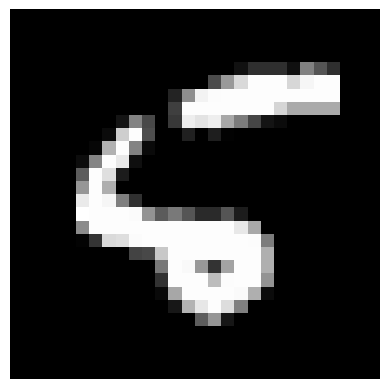

In [24]:
# 顯示第 9 筆圖像
X2: torch.Tensor = test_ds[i][0]
plt.imshow(X2.reshape(28, 28), cmap='gray')
plt.axis('off')
plt.show()

## 步驟8：評估，暫不進行

## 步驟9：模型佈署

In [25]:
# 模型存檔
torch.save(model, 'model.pt')

# 模型載入
model: nn.Sequential = torch.load('model.pt', weights_only=False)

In [26]:
# 權重存檔
torch.save(model.state_dict(), 'model.pth')

# 權重載入
model.load_state_dict(torch.load('model.pth'))

<All keys matched successfully>

In [27]:
# 顯示每一層的 state_dict 維度
print("每一層的 state_dict:")
for param_tensor in model.state_dict():
    print(param_tensor, "\t", model.state_dict()[param_tensor].size())

每一層的 state_dict:
1.weight 	 torch.Size([256, 784])
1.bias 	 torch.Size([256])
3.weight 	 torch.Size([10, 256])
3.bias 	 torch.Size([10])


## 步驟10：新資料預測

In [28]:
# 使用小畫家，繪製 0~9，實際測試看看
# 讀取影像並轉為單色
# image to a Torch tensor
transform = transforms.Compose(
    [transforms.Grayscale(num_output_channels=1), transforms.Resize([28, 28]), transforms.PILToTensor()]
)
for i in range(10):
    uploaded_file = f'myDigits/{i}.png'
    image = Image.open(uploaded_file)
    X1 = cast(torch.Tensor, transform(image))
    X1 = torch.FloatTensor(255.0 - X1).to(device)
    pred: torch.Tensor = model(X1)
    print(f'actual/prediction: {i} {pred.argmax(dim=1).item()}')

actual/prediction: 0 0
actual/prediction: 1 1
actual/prediction: 2 2
actual/prediction: 3 7
actual/prediction: 4 4
actual/prediction: 5 5
actual/prediction: 6 6
actual/prediction: 7 3
actual/prediction: 8 8
actual/prediction: 9 8


## 其他：顯示模型彙總資訊(summary)、繪製圖形顯示模型結構

In [29]:
print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=256, out_features=10, bias=True)
)


In [30]:
# 顯示模型的彙總資訊
for name, module in model.named_children():
    print(f'{name}: {module}')

0: Flatten(start_dim=1, end_dim=-1)
1: Linear(in_features=784, out_features=256, bias=True)
2: Dropout(p=0.2, inplace=False)
3: Linear(in_features=256, out_features=10, bias=True)


In [31]:
!pip install torchinfo

In [32]:
summary(model, (60000, 28, 28))  # input dimension size

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [60000, 10]               --
├─Flatten: 1-1                           [60000, 784]              --
├─Linear: 1-2                            [60000, 256]              200,960
├─Dropout: 1-3                           [60000, 256]              --
├─Linear: 1-4                            [60000, 10]               2,570
Total params: 203,530
Trainable params: 203,530
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 12.21
Input size (MB): 188.16
Forward/backward pass size (MB): 127.68
Params size (MB): 0.81
Estimated Total Size (MB): 316.65

## PyTorch 無法繪製模型